# Stage 4: Gene-Median Estimation by Scatter-Gather Processing

## Stage Objective

Estimate robust expression medians for the rat training corpus and combine them with compatible GeneCompass medians for token ranking.

## Workflow

| Step | Operation | Analytical purpose |
|------|-----------|--------------------|
| 1 | Scatter | Compute per-file nonzero-expression summaries across quality-controlled matrices. |
| 2 | Gather | Aggregate file-level summaries into corpus-level rat gene medians. |
| 3 | Filtering | Apply the documented coverage criteria to identify eligible genes. |
| 4 | Hybrid construction | Use compatible human medians when available and rat corpus medians otherwise. |

## Inputs and Outputs

| Component | Description |
|-----------|-------------|
| Inputs | Stage 2 quality-controlled `.h5ad` files and Stage 3 cross-species mappings. |
| Primary outputs | `data/training/gene_medians/hybrid_gene_medians.pickle` and median provenance reports. |

## Result Overview

The hybrid median vector supplies the normalization denominator used during Stage 5 rank-based tokenization.

The sections below present the computational evidence in execution order. All reported figures are generated from the recorded stage outputs rather than manually entered plotting values unless explicitly identified as configuration constants.


In [ ]:
import json
import csv
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path('..')
MEDIAN_DIR   = PROJECT_ROOT / 'data/training/gene_medians'
ORTH_DIR     = PROJECT_ROOT / 'data/training/ortholog_mappings'
GC_SCDATA    = PROJECT_ROOT / 'vendor/GeneCompass/scdata/dict'

print(f"Median dir  : {MEDIAN_DIR}")
print()
print("Output files:")
for fname in sorted(MEDIAN_DIR.iterdir()):
    if fname.is_file():
        print(f"  {fname.name:<40s}  {fname.stat().st_size/1e3:>8.1f} KB")


Median dir  : ../data/training/gene_medians

Output files:
  biotype_summary.json                           0.7 KB
  cell_stats_summary.json                        0.2 KB
  gene_median_stats.npz                        848.4 KB
  gene_median_stats.tsv                       3869.2 KB
  hybrid_gene_medians.pickle                   641.5 KB
  hybrid_median_provenance.json                736.4 KB
  rat_gene_medians.pickle                      641.5 KB
  stage4_manifest.json                           2.4 KB


## Step 1+2: Scatter/Gather Results

The scatter step ran as a 50-task SLURM array on Gilbreth, each task processing a
non-overlapping slice of the h5ad corpus. The gather step merged results and applied
the `min_nonzero_cells = 10` filter — genes seen in fewer than 10 cells across the
entire corpus are excluded from the median output.


In [ ]:
with open(MEDIAN_DIR / 'stage4_manifest.json') as f:
    manifest = json.load(f)
with open(MEDIAN_DIR / 'biotype_summary.json') as f:
    biotype = json.load(f)
with open(MEDIAN_DIR / 'cell_stats_summary.json') as f:
    cell_stats = json.load(f)

cfg = manifest['config_snapshot']
inp = manifest['inputs']
out = manifest['outputs']

print(f"stage4_manifest.json  (generated {manifest['generated_at'][:10]})")
print(f"  Elapsed:               {manifest['elapsed_s']/60:.1f} min ({manifest['elapsed_s']:.0f}s)")
print()
print("  Config:")
print(f"    target_sum           : {cfg['target_sum']:,}  (normalize_total per cell)")
print(f"    min_nonzero_cells    : {cfg['min_nonzero_cells']}")
print(f"    ensembl_release      : {cfg['ensembl_release']}")
print()
print("  Inputs:")
print(f"    SLURM scatter tasks  : {inp['n_scatter_tasks']}")
print(f"    h5ad files processed : {inp['total_files_processed']:,}")
print(f"    Cells processed      : {inp['total_cells_processed']:,}")
print()
print("  Outputs:")
print(f"    Universe genes       : {out['n_universe_genes']:,}")
print(f"    Genes with median    : {out['n_genes_with_median']:,}")
print(f"    Genes pass filter    : {out['n_genes_pass_filter']:,}")
print(f"    Genes excluded       : {out['n_genes_excluded_by_filter']:,}")
print()
print("  Cell stats (across corpus):")
print(f"    Files               : {cell_stats['n_files']:,}")
print(f"    Total cells         : {cell_stats['total_cells']:,}")
print(f"    Mean library size   : {cell_stats['lib_size_mean_of_file_means']:,.0f}  (mean of per-file means)")
print(f"    Median library size : {cell_stats['lib_size_median_of_file_medians']:,.0f}  (median of per-file medians)")
print(f"    Mean genes/cell     : {cell_stats['n_genes_mean_of_file_means']:,.0f}")
print()
print("  Biotype summary (pass filter):")
print(f"  {'Biotype':<15s} {'total':>7s} {'pass':>7s} {'excl':>6s}  {'med-of-meds':>12s}  {'mean_zero_frac':>14s}")
for bt, bs in biotype.items():
    excl = bs['n_total'] - bs['n_pass_filter']
    print(f"  {bt:<15s} {bs['n_total']:>7,} {bs['n_pass_filter']:>7,} {excl:>6,}  "
          f"{bs['median_of_medians']:>12.4f}  {bs['mean_zero_fraction']:>14.4f}")


stage4_manifest.json  (generated 2026-03-16)
  Elapsed:               55.2 min (3312s)

  Config:
    target_sum           : 10,000  (normalize_total per cell)
    min_nonzero_cells    : 10
    ensembl_release      : 113

  Inputs:
    SLURM scatter tasks  : 50
    h5ad files processed : 864
    Cells processed      : 9,483,420

  Outputs:
    Universe genes       : 22,213
    Genes with median    : 22,213
    Genes pass filter    : 21,379
    Genes excluded       : 834

  Cell stats (across corpus):
    Files               : 864
    Total cells         : 9,483,420
    Mean library size   : 4,062  (mean of per-file means)
    Median library size : 2,448  (median of per-file medians)
    Mean genes/cell     : 1,367

  Biotype summary (pass filter):
  Biotype           total    pass   excl   med-of-meds  mean_zero_frac
  lncrna            1,275   1,229     46        1.6220          0.9878
  mirna               211     155     56        2.3001          0.9999
  protein_coding   20,727  19

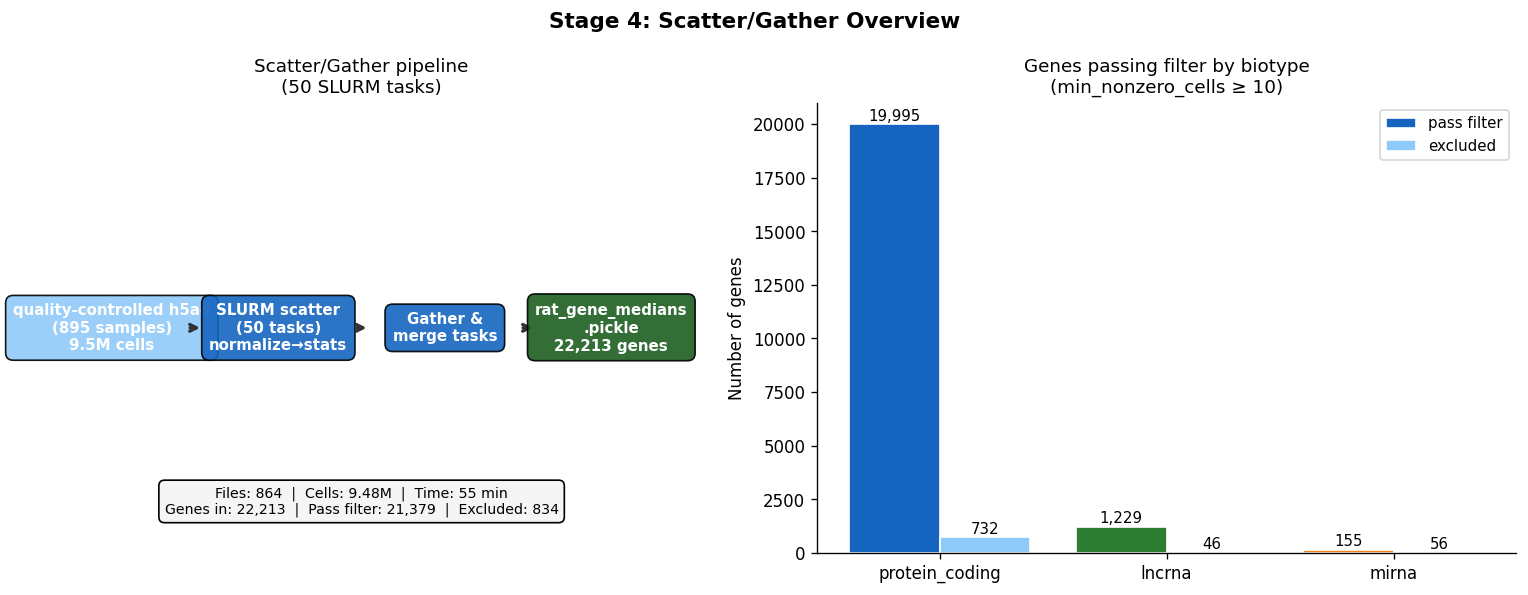

In [ ]:
with open(MEDIAN_DIR / 'stage4_manifest.json') as f:
    manifest = json.load(f)
with open(MEDIAN_DIR / 'biotype_summary.json') as f:
    biotype = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stage 4: Scatter/Gather Overview', fontsize=13, fontweight='bold')

ax = axes[0]
steps_txt = ["quality-controlled h5ad\n(895 samples)\n9.5M cells", 'SLURM scatter\n(50 tasks)\nnormalize→stats',
             'Gather &\nmerge tasks', 'rat_gene_medians\n.pickle\n22,213 genes']
clrs_s = ['#90CAF9','#1565C0','#1565C0','#1B5E20']
for x, s, c in zip([0,1,2,3], steps_txt, clrs_s):
    ax.text(x, 0.5, s, ha='center', va='center', fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=c, alpha=0.9))
    if x < 3:
        ax.annotate('', xy=(x+0.55,0.5), xytext=(x+0.45,0.5),
                    arrowprops=dict(arrowstyle='->', color='#333333', lw=2))
ax.set_xlim(-0.6,3.6); ax.set_ylim(0,1); ax.axis('off')
ax.set_title('Scatter/Gather pipeline\n(50 SLURM tasks)', fontsize=11)
inp = manifest['inputs']
out = manifest['outputs']
ax.text(1.5, 0.08, f"Files: {inp['total_files_processed']:,}  |  Cells: {inp['total_cells_processed']/1e6:.2f}M  |  "
        f"Time: {manifest['elapsed_s']/60:.0f} min\n"
        f"Genes in: {out['n_universe_genes']:,}  |  Pass filter: {out['n_genes_pass_filter']:,}  |  "
        f"Excluded: {out['n_genes_excluded_by_filter']:,}",
        ha='center', va='bottom', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F5F5'))

ax = axes[1]
bts = ['protein_coding','lncrna','mirna']
n_pass = [biotype[b]['n_pass_filter'] for b in bts]
n_fail = [biotype[b]['n_total'] - biotype[b]['n_pass_filter'] for b in bts]
clrs_p = ['#1565C0','#2E7D32','#F57F17']; clrs_f = ['#90CAF9','#A5D6A7','#FFCC80']
x = np.arange(len(bts)); width = 0.4
b1 = ax.bar(x-width/2, n_pass, width, color=clrs_p, label='pass filter', edgecolor='white')
b2 = ax.bar(x+width/2, n_fail, width, color=clrs_f, label='excluded', edgecolor='white')
for bar, v in [(b, n) for b, n in zip(list(b1)+list(b2), n_pass+n_fail)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, f'{v:,}',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(bts, fontsize=10)
ax.set_ylabel('Number of genes')
ax.set_title(f'Genes passing filter by biotype\n(min_nonzero_cells ≥ 10)', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()


## Gene Median Statistics

`gene_median_stats.tsv` contains one row per gene with detailed statistics:

| Column | Description |
|--------|-------------|
| `median_norm` | Median normalized count (after `normalize_total(10,000)`) |
| `p25_norm`, `p75_norm`, `p95_norm` | Percentiles of normalized counts |
| `mean_norm_nonzero` | Mean among cells with non-zero expression |
| `zero_fraction_norm` | Fraction of cells with zero expression |
| `median_raw` | Median raw count (1.0 = most common, reflecting integer counts) |
| `n_nonzero_norm` | Number of cells with non-zero expression |

The **zero fraction** is particularly important: most genes are sparse, expressed in
< 5% of cells in a typical single-cell dataset. The median is computed only over
non-zero cells (GeneCompass convention), so a gene expressed in 1% of cells at level
3 gets `median = 3.0`.


In [ ]:
rows = []
with open(MEDIAN_DIR / 'gene_median_stats.tsv') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        rows.append(row)

pass_rows = [r for r in rows if r['pass_filter'] == '1']
by_bt = {}
for r in pass_rows:
    by_bt.setdefault(r['biotype'], []).append(r)

print(f"gene_median_stats.tsv: {len(rows):,} genes total, {len(pass_rows):,} pass filter")
print()

print("Distribution of median_norm (pass_filter=1):")
vals = [float(r['median_norm']) for r in pass_rows]
p5, p25, p50, p75, p95 = np.percentile(vals, [5,25,50,75,95])
print(f"  min={min(vals):.3f}  p5={p5:.3f}  q1={p25:.3f}  med={p50:.3f}  "
      f"q3={p75:.3f}  p95={p95:.3f}  max={max(vals):.3f}")
print()

print("Distribution of zero_fraction_norm (pass_filter=1):")
zf = [float(r['zero_fraction_norm']) for r in pass_rows]
p5z, p25z, p50z, p75z, p95z = np.percentile(zf, [5,25,50,75,95])
print(f"  min={min(zf):.3f}  p5={p5z:.3f}  q1={p25z:.3f}  med={p50z:.3f}  "
      f"q3={p75z:.3f}  p95={p95z:.3f}  max={max(zf):.3f}")
print()

print("Per-biotype median summary:")
print(f"  {'biotype':<15s} {'n':>6s} {'median(med)':>12s} {'Q1(med)':>10s} {'Q3(med)':>10s} {'med(zero_frac)':>15s}")
for bt in ['protein_coding','lncrna','mirna']:
    br = by_bt.get(bt,[])
    if not br: continue
    mv = [float(r['median_norm']) for r in br]
    zv = [float(r['zero_fraction_norm']) for r in br]
    print(f"  {bt:<15s} {len(mv):>6,} {np.median(mv):>12.4f} {np.percentile(mv,25):>10.4f} "
          f"{np.percentile(mv,75):>10.4f} {np.median(zv):>15.4f}")


gene_median_stats.tsv: 22,213 genes total, 21,379 pass filter

Distribution of median_norm (pass_filter=1):
  min=0.156  p5=1.165  q1=2.090  med=2.703  q3=3.741  p95=7.893  max=159.119

Distribution of zero_fraction_norm (pass_filter=1):
  min=0.122  p5=0.775  q1=0.910  med=0.969  q3=0.996  p95=1.000  max=1.000

Per-biotype median summary:
  biotype              n  median(med)    Q1(med)    Q3(med)  med(zero_frac)
  protein_coding  19,995       2.7541     2.1496     3.8081          0.9637
  lncrna           1,229       1.6180     1.0837     2.4848          0.9985
  mirna              155       2.3857     1.8486     3.4739          1.0000


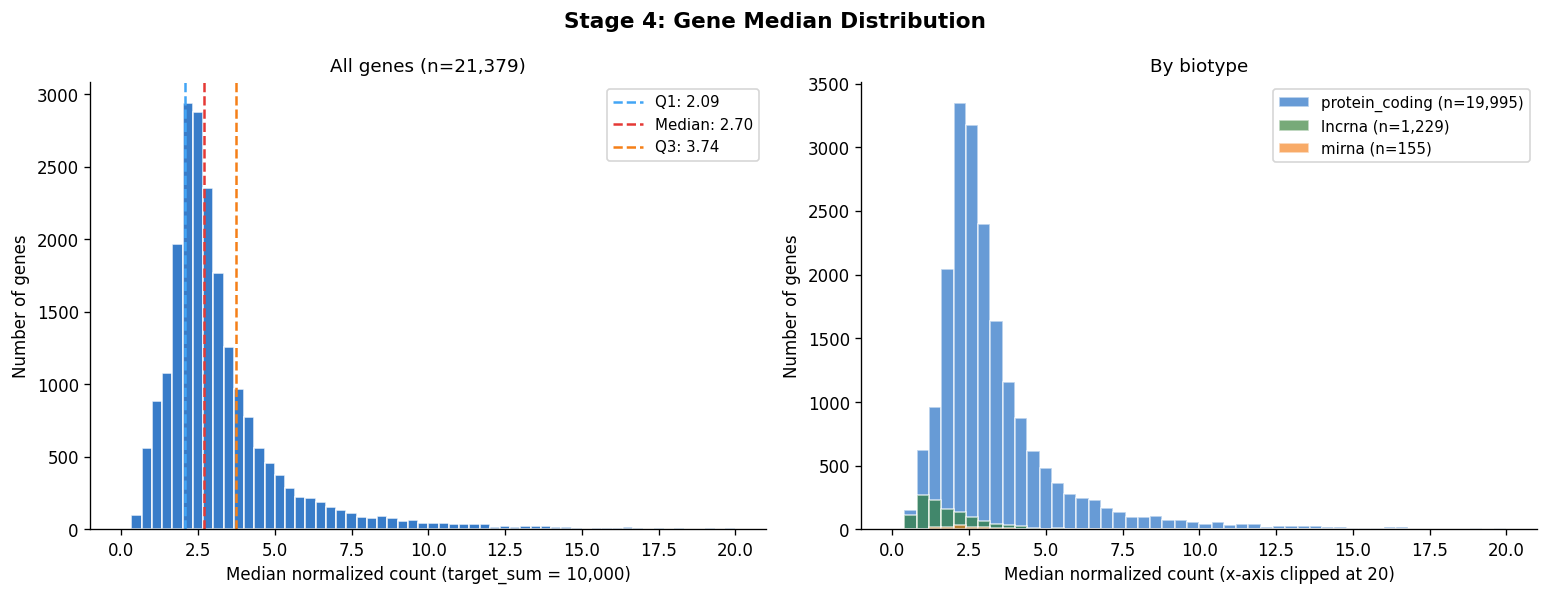

In [ ]:
rows = []
with open(MEDIAN_DIR / 'gene_median_stats.tsv') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        rows.append(row)
pass_rows = [r for r in rows if r['pass_filter'] == '1']
by_bt = {}
for r in pass_rows:
    by_bt.setdefault(r['biotype'], []).append(r)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stage 4: Gene Median Distribution', fontsize=13, fontweight='bold')

ax = axes[0]
all_meds = [float(r['median_norm']) for r in pass_rows]
ax.hist(all_meds, bins=60, color='#1565C0', alpha=0.85, edgecolor='white', range=(0,20))
ax.set_xlabel('Median normalized count (target_sum = 10,000)')
ax.set_ylabel('Number of genes')
ax.set_title(f'All genes (n={len(all_meds):,})', fontsize=11)
p25, p50, p75 = np.percentile(all_meds, [25,50,75])
for p, label, clr in [(p25,'Q1','#42A5F5'),(p50,'Median','#E53935'),(p75,'Q3','#F57F17')]:
    ax.axvline(p, color=clr, linestyle='--', linewidth=1.5, label=f'{label}: {p:.2f}')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
clrs_bt = {'protein_coding':'#1565C0','lncrna':'#2E7D32','mirna':'#F57F17'}
for bt in ['protein_coding','lncrna','mirna']:
    vals = [float(r['median_norm']) for r in by_bt.get(bt,[])]
    ax.hist(vals, bins=50, alpha=0.65, color=clrs_bt[bt],
            label=f'{bt} (n={len(vals):,})', edgecolor='white', range=(0,20))
ax.set_xlabel('Median normalized count (x-axis clipped at 20)')
ax.set_ylabel('Number of genes')
ax.set_title('By biotype', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()


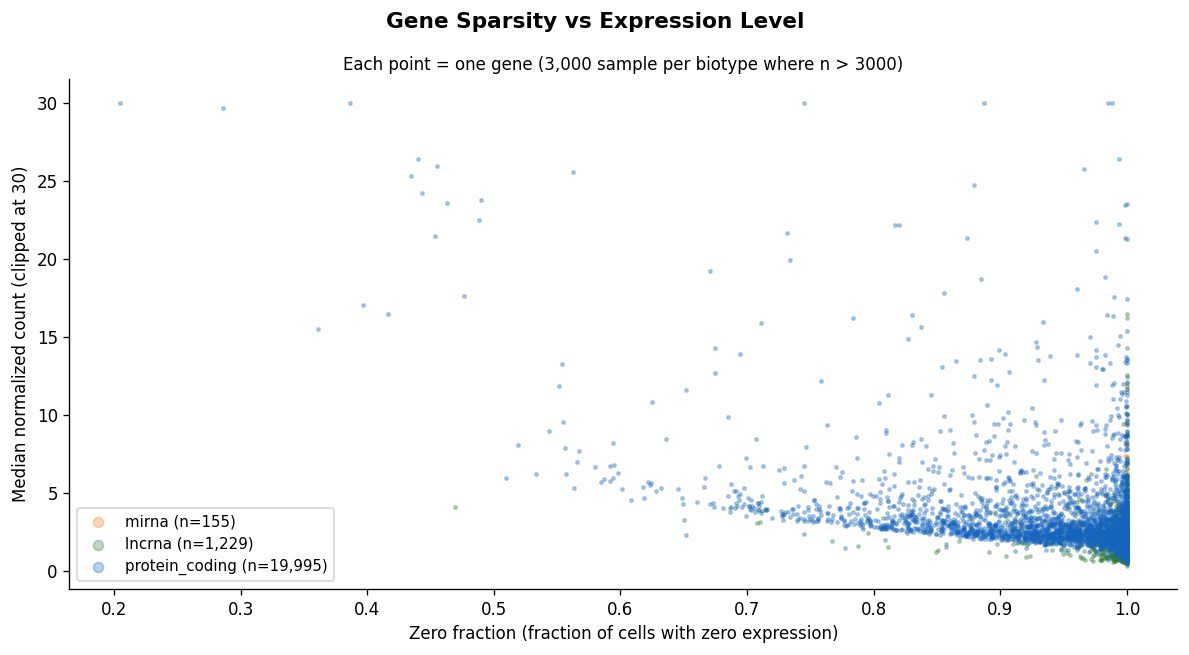

In [ ]:
rows = []
with open(MEDIAN_DIR / 'gene_median_stats.tsv') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        rows.append(row)
pass_rows = [r for r in rows if r['pass_filter'] == '1']
by_bt = {}
for r in pass_rows:
    by_bt.setdefault(r['biotype'], []).append(r)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.suptitle('Gene Sparsity vs Expression Level', fontsize=13, fontweight='bold')

clrs_bt = {'protein_coding':'#1565C0','lncrna':'#2E7D32','mirna':'#F57F17'}
np.random.seed(42)
for bt in ['mirna','lncrna','protein_coding']:
    br = by_bt.get(bt,[])
    zf = [float(r['zero_fraction_norm']) for r in br]
    mn = [min(float(r['median_norm']),30) for r in br]
    idx = np.random.choice(len(zf), min(3000,len(zf)), replace=False)
    ax.scatter([zf[i] for i in idx], [mn[i] for i in idx],
               c=clrs_bt[bt], alpha=0.3, s=4, label=f'{bt} (n={len(zf):,})')

ax.set_xlabel('Zero fraction (fraction of cells with zero expression)')
ax.set_ylabel('Median normalized count (clipped at 30)')
ax.set_title('Each point = one gene (3,000 sample per biotype where n > 3000)', fontsize=10)
ax.legend(fontsize=9, markerscale=3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## Hybrid Gene Median (`hybrid_gene_medians.pickle`)

GeneCompass pretraining used human gene medians to normalize before tokenization.
To maximize embedding transfer, Stage 4 produces a **hybrid** median dictionary:

```
For each rat gene in pruned_gene_universe:
  if gene has rat→human mapping (Tiers T1-T3):
      median = human GeneCompass median  (human_gene_median_after_filter.pickle)
  else (Tier T4, no ortholog):
      median = rat corpus median         (rat_gene_medians.pickle)
```

This means tokenized rat cells will have the same normalization baseline as the
human cells GeneCompass was pretrained on, for all genes where the comparison is
biologically valid. Tier 4 genes use rat-native medians.

**Validation:** Empirical comparison against GeneCompass's `randsel_5w_mouse` reference:
- Median offset: −0.075 (very close to zero; value distributions align well)
- Std offset: −0.096 vs reference std of 0.63 (< 15% deviation)


In [ ]:
with open(MEDIAN_DIR / 'hybrid_median_provenance.json') as f:
    prov = json.load(f)

print(f"hybrid_median_provenance.json  (generated {prov['generated_at'][:10]})")
print()
print("  Inputs:")
for k, v in prov['inputs'].items():
    print(f"    {k:<40s} {Path(v).name}")
print()
print("  Coverage:")
cov = prov['coverage']
print(f"    Total genes          : {cov['total_genes']:>6,}")
print(f"    Human median used    : {cov['human_median']:>6,}  ({cov['pct_human']:.1f}%)")
print(f"    Rat median used      : {cov['rat_median']:>6,}  ({cov['pct_rat']:.1f}%)")
print(f"    Fallback             : {cov['fallback']:>6,}")
print()
print("  Hybrid median value distribution:")
vs = prov['value_stats']
print(f"    min    : {vs['min']:.4f}")
print(f"    mean   : {vs['mean']:.4f}")
print(f"    median : {vs['median']:.4f}")
print(f"    max    : {vs['max']:.4f}")
print()
print(f"  Note: {prov['normalization_note']}")

# Load rat_gene_medians.pickle and sample
with open(MEDIAN_DIR / 'rat_gene_medians.pickle', 'rb') as f:
    rat_medians = pickle.load(f)
print()
print(f"  rat_gene_medians.pickle: {len(rat_medians):,} genes")
sample_items = list(rat_medians.items())[:5]
print(f"  Sample entries: {sample_items}")


hybrid_median_provenance.json  (generated 2026-03-17)

  Inputs:
    rat_gene_medians                         rat_gene_medians.pickle
    rat_to_human_mapping                     rat_to_human_mapping.pickle
    human_gene_median_after_filter           human_gene_median_after_filter.pickle

  Coverage:
    Total genes          : 21,379
    Human median used    : 14,812  (69.3%)
    Rat median used      :  6,567  (30.7%)
    Fallback             :      0

  Hybrid median value distribution:
    min    : 0.1100
    mean   : 2.1869
    median : 1.4700
    max    : 91.3303

  Note: Raw counts are divided directly by these medians (no normalize_total). Empirical comparison against randsel_5w_mouse: median offset -0.075, std offset -0.096 vs reference 0.63.

  rat_gene_medians.pickle: 21,379 genes
  Sample entries: [('ENSRNOG00000000001', 4.950540542602539), ('ENSRNOG00000000007', 6.779661178588867), ('ENSRNOG00000000008', 2.743609666824341), ('ENSRNOG00000000009', 2.4783146381378174), ('ENSR

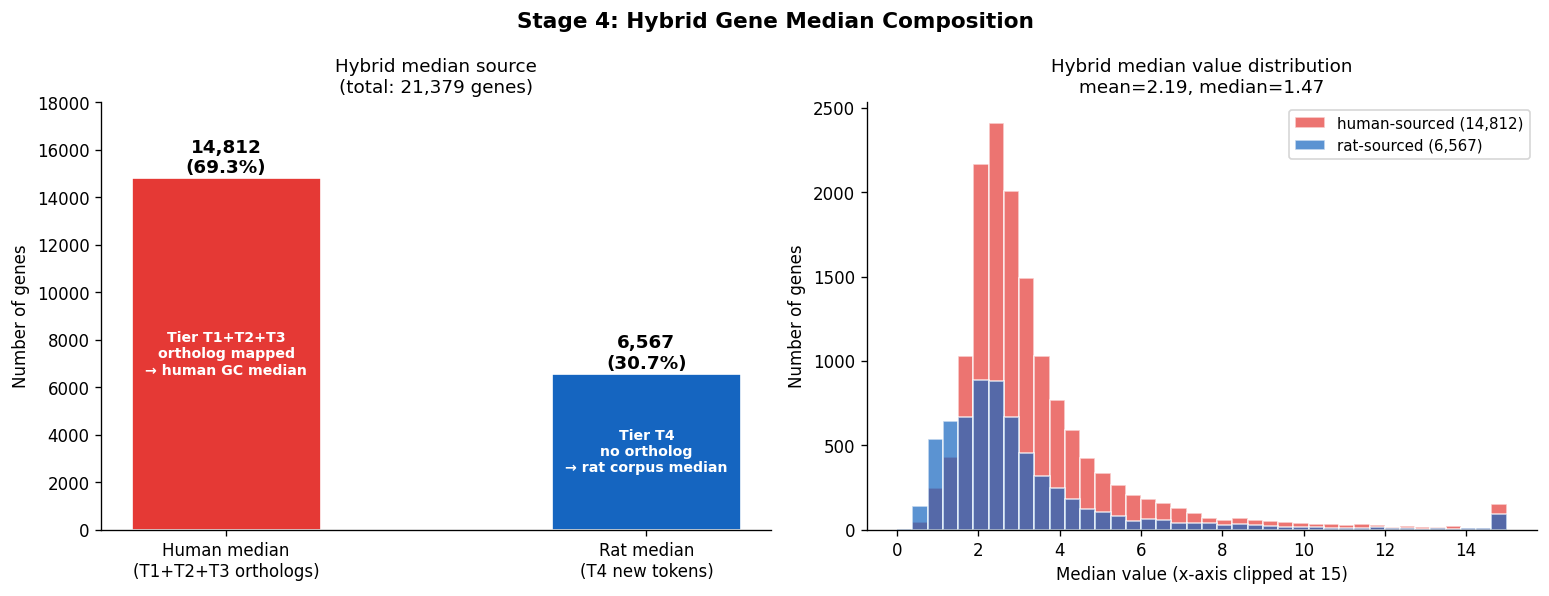

In [ ]:
with open(MEDIAN_DIR / 'hybrid_median_provenance.json') as f:
    prov = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stage 4: Hybrid Gene Median Composition', fontsize=13, fontweight='bold')

ax = axes[0]
cov = prov['coverage']
cats = ['Human median\n(T1+T2+T3 orthologs)', 'Rat median\n(T4 new tokens)']
vals = [cov['human_median'], cov['rat_median']]
clrs_h = ['#E53935','#1565C0']
bars = ax.bar(cats, vals, color=clrs_h, width=0.45, edgecolor='white')
for bar, v, pct in zip(bars, vals, [cov['pct_human'], cov['pct_rat']]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.text(0, cov['human_median']/2, 'Tier T1+T2+T3\northolog mapped\n→ human GC median',
        ha='center', va='center', fontsize=8.5, color='white', fontweight='bold')
ax.text(1, cov['rat_median']/2, 'Tier T4\nno ortholog\n→ rat corpus median',
        ha='center', va='center', fontsize=8.5, color='white', fontweight='bold')
ax.set_ylabel('Number of genes')
ax.set_title(f'Hybrid median source\n(total: {cov["total_genes"]:,} genes)', fontsize=11)
ax.set_ylim(0, 18000)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
# Load and plot hybrid median value distribution
rows = []
with open(MEDIAN_DIR / 'gene_median_stats.tsv') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        rows.append(row)
pass_rows = [r for r in rows if r['pass_filter']=='1']
rat_vals_all = [float(r['median_norm']) for r in pass_rows]

with open(MEDIAN_DIR / 'hybrid_median_provenance.json') as f:
    prov = json.load(f)
per_gene_src = prov.get('per_gene_source', {})

# Split rat vs human if available
rat_gene_meds = [float(r['median_norm']) for r in pass_rows
                 if per_gene_src.get(r['rat_gene']) == 'rat']
hum_gene_meds = [float(r['median_norm']) for r in pass_rows
                 if per_gene_src.get(r['rat_gene']) == 'human']

ax.hist([min(v,15) for v in hum_gene_meds], bins=40, alpha=0.7, color='#E53935',
        label=f'human-sourced ({len(hum_gene_meds):,})', edgecolor='white', range=(0,15))
ax.hist([min(v,15) for v in rat_gene_meds], bins=40, alpha=0.7, color='#1565C0',
        label=f'rat-sourced ({len(rat_gene_meds):,})', edgecolor='white', range=(0,15))
vs = prov['value_stats']
ax.set_xlabel('Median value (x-axis clipped at 15)')
ax.set_ylabel('Number of genes')
ax.set_title(f'Hybrid median value distribution\nmean={vs["mean"]:.2f}, median={vs["median"]:.2f}', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()


## Stage 4 Summary

Stage 4 produces the normalization reference that Stage 5 needs to tokenize rat cells
in a way that is compatible with GeneCompass pretraining:

| Downstream | File consumed | Purpose |
|------------|--------------|---------|
| Stage 5 | `hybrid_gene_medians.pickle` | Divide raw counts → log₂ → rank → top-2048 |
| Aim 2 | `gene_median_stats.tsv` | Zero fraction as edge weight in GRN reconstruction |
| Aim 3 | `zero_fraction`, biotype | Filter translation claims for highly sparse genes |

The primary deliverable is `hybrid_gene_medians.pickle`: a 21,379-entry dictionary
mapping each rat ENSRNOG to its normalization median. For 69.3% of genes this is
the human GeneCompass median; for 30.7% (T4 genes) it is the rat corpus median.


In [ ]:
with open(MEDIAN_DIR / 'stage4_manifest.json') as f:
    manifest = json.load(f)
with open(MEDIAN_DIR / 'hybrid_median_provenance.json') as f:
    prov = json.load(f)

print("=" * 60)
print("STAGE 4: GENE MEDIANS — SUMMARY")
print("=" * 60)
print()
out = manifest['outputs']
print("  Scatter/Gather:")
print(f"    SLURM tasks         : {manifest['inputs']['n_scatter_tasks']}")
print(f"    h5ad files          : {manifest['inputs']['total_files_processed']:,} / 895")
print(f"    Cells processed     : {manifest['inputs']['total_cells_processed']:,}")
print(f"    Elapsed             : {manifest['elapsed_s']/60:.1f} min")
print()
print("  Gene median filter (min_nonzero_cells=10):")
print(f"    Universe genes      : {out['n_universe_genes']:,}")
print(f"    Genes with median   : {out['n_genes_with_median']:,}")
print(f"    Pass filter (→ S5)  : {out['n_genes_pass_filter']:,}")
print(f"    Excluded            : {out['n_genes_excluded_by_filter']:,}")
print()
cov = prov['coverage']
print("  Hybrid median ({} genes):".format(cov['total_genes']))
print(f"    Human GC median     : {cov['human_median']:,}  ({cov['pct_human']:.1f}%)")
print(f"    Rat corpus median   : {cov['rat_median']:,}  ({cov['pct_rat']:.1f}%)")
print(f"    Value range         : {prov['value_stats']['min']:.2f} – {prov['value_stats']['max']:.2f}")
print()
print("  Primary outputs:")
for fname, path in manifest['output_files'].items():
    size_kb = Path(path).stat().st_size / 1024 if Path(path).exists() else 0
    print(f"    {fname:<35s}  {size_kb:>7.1f} KB")
print()
print("  Next step:")
print("    Stage 5 → Reference Assembly & Tokenization")
print("             reads hybrid_gene_medians.pickle")
print("             produces tokenized_corpus/ (ranked top-2048 gene lists)")


STAGE 4: GENE MEDIANS — SUMMARY

  Scatter/Gather:
    SLURM tasks         : 50
    h5ad files          : 864 / 895
    Cells processed     : 9,483,420
    Elapsed             : 55.2 min

  Gene median filter (min_nonzero_cells=10):
    Universe genes      : 22,213
    Genes with median   : 22,213
    Pass filter (→ S5)  : 21,379
    Excluded            : 834

  Hybrid median (21379 genes):
    Human GC median     : 14,812  (69.3%)
    Rat corpus median   : 6,567  (30.7%)
    Value range         : 0.11 – 91.33

  Primary outputs:
    rat_gene_medians.pickle                626.5 KB
    gene_median_stats.tsv                 3778.5 KB
    gene_median_stats.npz                  828.5 KB
    biotype_summary.json                     0.7 KB
    cell_stats_summary.json                  0.2 KB

  Next step:
    Stage 5 → Reference Assembly & Tokenization
             reads hybrid_gene_medians.pickle
             produces tokenized_corpus/ (ranked top-2048 gene lists)


## Stage Summary

Stage 4 aggregates expression evidence without loading the complete corpus into memory, filters genes with inadequate support, and records the source of every hybrid median. The resulting vector is the normalization reference used by Stage 5.


---
## Reproducibility Notes

| Item | Value |
|------|-------|
| Python version | 3.12 |
| Key packages | `scanpy`, `anndata`, `numpy`, `pandas`, `scipy` |
| Stage 4 median manifest date | 2026-03-16 |
| Hybrid median provenance date | 2026-03-17 |
| Scatter task count | 50 tasks in the production SLURM run; serial orchestrator uses one local task |
| Config file | `config/pipeline_config.yaml` — `medians`, `paths`, and `biomart` sections |

**To re-run Stage 4 from scratch:**
```bash
export PIPELINE_ROOT=..
source ../motrpac-env/bin/activate
cd $PIPELINE_ROOT
python pipeline/run_stage4.py                    # serial scatter + gather run
python pipeline/run_stage4.py --from 2           # resume at gather after scatter outputs exist
python pipeline/run_stage4.py --dry-run          # validate inputs/config only
python pipeline/run_stage4.py -v                 # verbose logging
```

**Production SLURM pattern:**
```bash
cd ..
sbatch slurm/pipeline/stage4_scatter.slurm       # scatter array job
sbatch slurm/pipeline/stage4_gather.slurm        # gather after scatter completion
```

**Known considerations:**
- Stage 4 depends on Stage 2 QC `.h5ad` files and Stage 3 `rat_token_mapping.tsv` / ortholog mapping outputs.
- `compute_gene_medians.py` normalizes in memory only; Stage 2 `.h5ad` files remain raw-count inputs.
- `hybrid_gene_medians.pickle` is produced after rat medians by combining GeneCompass human medians for ortholog-mapped genes with rat corpus medians for Tier 4 genes.
